# nextnano++ Run Template


This notebook is a reusable example for running a nextnano++ simulation, saving its outputs, and inspecting the most important results with `src/nextnanopp_tools.py`.

It is configured by default for the input file `Double_Quantum_Dot_2D_no_screening_charge.in`, which is intended to fix the screening-charge issue. Single-run outputs are saved directly as `runs/<input_stem>__<timestamp>[__tag]`, so repeated runs do not overwrite earlier calculations.


## 0. Setup


### - Imports


Import the libraries needed to run nextnano++, load the new helper module, and display static as well as interactive plots.

Interactive plotting helpers return Plotly figures and also display them directly in the notebook, so when you switch `interactive=True` you should not add `plt.show()` afterwards.

In [46]:
import os
import sys
import importlib
import importlib.metadata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import nextnanopy as nn
from IPython.display import display

print('Python:', sys.version)
print('CWD:', os.getcwd())
print('nextnanopy version:', importlib.metadata.version('nextnanopy'))

REPO_ROOT = Path('/Users/robertjovanov/code/qpu-design-automation-toolkit')
SRC = REPO_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import nextnanopp_tools as nnt
importlib.reload(nnt)

print('Helper module:', nnt.__file__)


Python: 3.11.13 (main, Jun  5 2025, 08:14:07) [Clang 14.0.6 ]
CWD: /Users/robertjovanov/code/qpu-design-automation-toolkit/notebooks/experiments
nextnanopy version: 1.0.3
Helper module: /Users/robertjovanov/code/qpu-design-automation-toolkit/src/nextnanopp_tools.py


### - Input and output configuration


Set the input file, the common `runs/` root, optional run tags, preferred line cuts, and the quantum region/band you want to inspect.

For single runs, the helper now creates output folders directly in the form `runs/<input_stem>__YYYYmmdd_HHMMSS` and optionally appends a custom tag such as `__test` or `__no_screening_fix`.


In [47]:
INPUT_PATH = REPO_ROOT / 'configs/robert_inputs/double_qd/2d/Double_Quantum_Dot_2D_no_screening_charge.in'
RUNS_ROOT = REPO_ROOT / 'runs'

# Single-run folders are created directly under RUNS_ROOT as:
#   <input_stem>__YYYYmmdd_HHMMSS
# or
#   <input_stem>__YYYYmmdd_HHMMSS__<tag>
RUN_TAG = None
FORCE_RERUN = False
REUSE_LATEST_RUN = True

BIAS_INDEX = 0
CUT_X = '1d_x_QD'
CUT_Z = '1d_z_BG2'
QUANTUM_REGION = 'c-Ge_QW'
QUANTUM_BAND = 'HH'

EXISTING_RUNS = nnt.find_runs_for_input(RUNS_ROOT, INPUT_PATH)
LATEST_EXISTING_RUN = EXISTING_RUNS[-1] if EXISTING_RUNS else None

config_summary = pd.Series({
    'INPUT_PATH': str(INPUT_PATH),
    'RUNS_ROOT': str(RUNS_ROOT),
    'RUN_TAG': RUN_TAG,
    'FORCE_RERUN': FORCE_RERUN,
    'REUSE_LATEST_RUN': REUSE_LATEST_RUN,
    'LATEST_EXISTING_RUN': str(LATEST_EXISTING_RUN) if LATEST_EXISTING_RUN else None,
    'BIAS_INDEX': BIAS_INDEX,
    'CUT_X': CUT_X,
    'CUT_Z': CUT_Z,
    'QUANTUM_REGION': QUANTUM_REGION,
    'QUANTUM_BAND': QUANTUM_BAND,
})
display(config_summary)

print('Input exists:', INPUT_PATH.exists())
print('Existing matching runs found:', len(EXISTING_RUNS))
for run in EXISTING_RUNS[-5:]:
    print(' -', run)


INPUT_PATH             /Users/robertjovanov/code/qpu-design-automatio...
RUNS_ROOT              /Users/robertjovanov/code/qpu-design-automatio...
RUN_TAG                                                             None
FORCE_RERUN                                                        False
REUSE_LATEST_RUN                                                    True
LATEST_EXISTING_RUN    /Users/robertjovanov/code/qpu-design-automatio...
BIAS_INDEX                                                             0
CUT_X                                                            1d_x_QD
CUT_Z                                                           1d_z_BG2
QUANTUM_REGION                                                   c-Ge_QW
QUANTUM_BAND                                                          HH
dtype: object

Input exists: True
Existing matching runs found: 1
 - /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_2D_no_screening_charge__20260419_163613


### - Quick reference


In [48]:
tools_overview = {
    'Run / sweep': [
        'build_run_name', 'make_timestamp_tag', 'load_input_file', 'run_input_file',
        'find_runs_for_input', 'find_latest_run', 'resolve_run_root',
        'run_sweep', 'find_sweep_subrun', 'get_run_paths', 'get_bias_dirs', 'get_bias_dir',
    ],
    'Diagnostics': [
        'convergence_summary', 'plot_convergence', 'read_total_charges',
        'plot_total_charges', 'read_integrated_density_hole',
        'map_integrated_density_regions', 'plot_integrated_density_hole',
    ],
    'Structure': [
        'build_region_material_map', 'plot_structure_linecut', 'plot_structure_plane',
    ],
    'Generic plotting': [
        'describe_output_file', 'load_output_file', 'list_variables',
        'plot_dat', 'plot_dat_interactive', 'plot_fld', 'plot_fld_interactive',
        'plot_vtr_slice', 'plot_vtr_slice_interactive', 'plot_vtr_linecut',
    ],
    'Bias wrappers': [
        'plot_bias_linecut', 'plot_bias_plane', 'plot_bias_volume_slice', 'plot_bias_volume_linecut',
    ],
    'Quantum': [
        'read_quantum_occupation', 'read_quantum_energy_spectrum',
        'plot_quantum_occupation', 'plot_quantum_energy_spectrum',
        'plot_quantum_linecut', 'plot_quantum_plane',
        'plot_quantum_probabilities_linecut', 'plot_quantum_probability_plane',
    ],
}

for group, funcs in tools_overview.items():
    print(f'[{group}]')
    for func in funcs:
        print(' -', func)
    print()


[Run / sweep]
 - build_run_name
 - make_timestamp_tag
 - load_input_file
 - run_input_file
 - find_runs_for_input
 - find_latest_run
 - resolve_run_root
 - run_sweep
 - find_sweep_subrun
 - get_run_paths
 - get_bias_dirs
 - get_bias_dir

[Diagnostics]
 - convergence_summary
 - plot_convergence
 - read_total_charges
 - plot_total_charges
 - read_integrated_density_hole
 - map_integrated_density_regions
 - plot_integrated_density_hole

[Structure]
 - build_region_material_map
 - plot_structure_linecut
 - plot_structure_plane

[Generic plotting]
 - describe_output_file
 - load_output_file
 - list_variables
 - plot_dat
 - plot_dat_interactive
 - plot_fld
 - plot_fld_interactive
 - plot_vtr_slice
 - plot_vtr_slice_interactive
 - plot_vtr_linecut

[Bias wrappers]
 - plot_bias_linecut
 - plot_bias_plane
 - plot_bias_volume_slice
 - plot_bias_volume_linecut

[Quantum]
 - read_quantum_occupation
 - read_quantum_energy_spectrum
 - plot_quantum_occupation
 - plot_quantum_energy_spectrum
 - plot_q

### - Preview the input variables (first 20)


In [4]:
inp_preview = nnt.load_input_file(INPUT_PATH)
preview_df = pd.DataFrame(
    {
        'name': [var.name for var in list(inp_preview.variables)[:20]],
        'value': [var.value for var in list(inp_preview.variables)[:20]],
        'comment': [getattr(var, 'comment', '') for var in list(inp_preview.variables)[:20]],
    }
)
display(preview_df)


,name,value,comment
0,strain,1,
1,poisson,1,
2,quantum,0,
3,quantum_poisson,1,
4,decomposition,0,should not be needed in 2D
5,n_c_Ge_QW_HH,50,
6,n_c_Ge_QW_LH,100,
7,temperature,0.01,(K)
8,V_BG1,0.0,(V)
9,V_PG1,-3.0,(V)


## 1. Run the simulation


This cell runs the input file with `nextnanopy.InputFile` through `nextnanopp_tools.run_input_file()`.

If a rerun is needed, a fresh folder is created directly under `runs/` using the pattern `input_stem__timestamp` and optional `__tag`. If `REUSE_LATEST_RUN = True`, the notebook reuses the latest matching run instead.


In [5]:
if FORCE_RERUN or not EXISTING_RUNS or not REUSE_LATEST_RUN:
    print('Running simulation...')
    inp = nnt.load_input_file(INPUT_PATH)
    inp = nnt.run_input_file(
        inp,
        output_root=RUNS_ROOT,
        tag=RUN_TAG,
        show_log=False,
        convergenceCheck=True,
    )
    RUN_ROOT = nnt.get_output_directory(inp)
else:
    print('Reusing latest matching run.')
    RUN_ROOT = nnt.find_latest_run(RUNS_ROOT, INPUT_PATH)

RUN_ROOT = nnt.resolve_run_root(RUN_ROOT)
RUN_PATHS = nnt.get_run_paths(RUN_ROOT)
BIAS0 = nnt.get_bias_dir(RUN_ROOT, bias=BIAS_INDEX)

print('RUN_ROOT:', RUN_ROOT)
print('Run name:', RUN_ROOT.name)
print('Structure folder:', RUN_PATHS.structure)
print('First bias folder:', BIAS0)
print('job_done:', (RUN_ROOT / 'job_done.txt').exists())


Running simulation...
RUN_ROOT: /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_2D_no_screening_charge__20260419_163613
Run name: Double_Quantum_Dot_2D_no_screening_charge__20260419_163613
Structure folder: /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_2D_no_screening_charge__20260419_163613/Structure
First bias folder: /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_2D_no_screening_charge__20260419_163613/bias_00000
job_done: True


### - Inspect the generated run tree


In [49]:
print('Bias directories:')
for path in nnt.get_bias_dirs(RUN_ROOT):
    print(' -', path.relative_to(RUN_ROOT))

print()
print('A few density-related files:')
for path in nnt.find_run_files(RUN_ROOT, 'density', deep=True)[:20]:
    print(' -', path.relative_to(RUN_ROOT))


Bias directories:
 - bias_00000

A few density-related files:
 - Structure/density_acceptor.fld
 - Structure/density_acceptor_1d_x_QD.dat
 - Structure/density_acceptor_1d_z_BG2.dat
 - Structure/density_acceptor_1d_z_PG1.dat
 - Structure/density_acceptor_1d_z_PG2.dat
 - Structure/density_fixed_charge.fld
 - Structure/density_fixed_charge_1d_x_QD.dat
 - Structure/density_fixed_charge_1d_z_BG2.dat
 - Structure/density_fixed_charge_1d_z_PG1.dat
 - Structure/density_fixed_charge_1d_z_PG2.dat
 - bias_00000/Quantum/c-Ge_QW/HH/density.fld
 - bias_00000/Quantum/c-Ge_QW/HH/density_1d_x_QD.dat
 - bias_00000/Quantum/c-Ge_QW/HH/density_1d_z_BG2.dat
 - bias_00000/Quantum/c-Ge_QW/HH/density_1d_z_PG1.dat
 - bias_00000/Quantum/c-Ge_QW/HH/density_1d_z_PG2.dat
 - bias_00000/Quantum/c-Ge_QW/LH/density.fld
 - bias_00000/Quantum/c-Ge_QW/LH/density_1d_x_QD.dat
 - bias_00000/Quantum/c-Ge_QW/LH/density_1d_z_BG2.dat
 - bias_00000/Quantum/c-Ge_QW/LH/density_1d_z_PG1.dat
 - bias_00000/Quantum/c-Ge_QW/LH/density_1

## 2. Convergence and fast accumulation diagnostics


Start with the fast diagnostics: residuals from `iteration_quantum_poisson.dat`, the integrated hole density, and the charge summary from `total_charges.txt`.


In [50]:
conv_summary = nnt.convergence_summary(BIAS0)
charges_df = nnt.read_total_charges(BIAS0)
integrated_df = nnt.read_integrated_density_hole(RUN_ROOT)
integrated_region_map = nnt.map_integrated_density_regions(RUN_ROOT, cut=CUT_Z)

display(pd.DataFrame([conv_summary['final_residuals']]))
display(charges_df)
display(integrated_df)
display(integrated_region_map)


,Residual_EDensity[1/cm],Residual_HDensity[1/cm],Residual_Potential[V]
0,0.0,433.2878,0.000002


,quantity,value,unit
0,electrons,-1.176517e-298,e/cm
1,holes,8.939396e+06,e/cm
2,ionized donors,0.000000e+00,e/cm
3,ionized acceptors,-0.000000e+00,e/cm
4,fixed charges,0.000000e+00,e/cm
5,polarization_total,0.000000e+00,e/cm
6,polarization_piezo,0.000000e+00,e/cm
7,sum,8.939396e+06,e/cm


,BG1_bias[V],PG1_bias[V],BG2_bias[V],PG2_bias[V],BG3_bias[V],Source_bias[V],Drain_bias[V],Body_bias[V],remove_surface_charge_bias[V],zero_fermi_QW_bias[V],region_3[carriers/cm],region_4[carriers/cm],region_7[carriers/cm]
0,0,0,0,0,0,0,0,0,-0.5,0,5315631.8,913441,2898950.1


,integrated_column,integrated_region_index,structure_region_index,region_index_offset,material_index,material_name,coord_min,coord_max,thickness_nm,n_points,cut
0,region_3[carriers/cm],3,2,1,8,Ge,-14.75,-0.25,14.5,30,1d_z_BG2
1,region_4[carriers/cm],4,3,1,16,Si(x)Ge(1-x),0.25,99.95,99.7,268,1d_z_BG2
2,region_7[carriers/cm],7,6,1,16,Si(x)Ge(1-x),100.05,100.95,0.9,10,1d_z_BG2


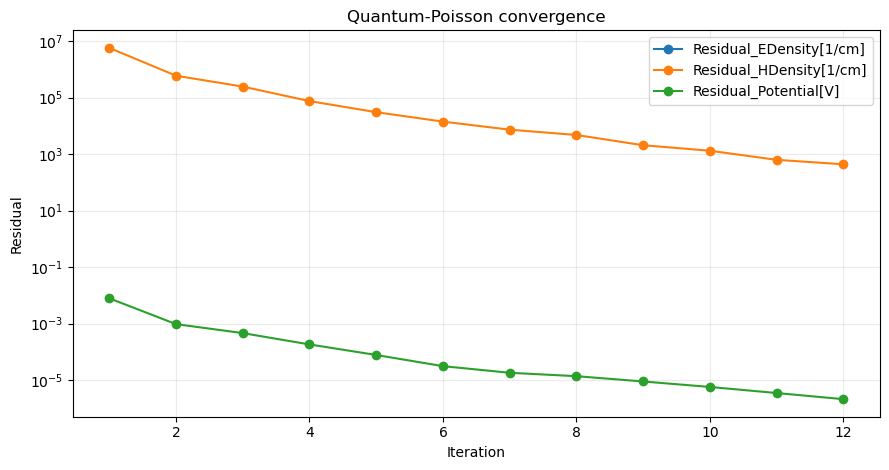

In [51]:
nnt.plot_convergence(BIAS0, interactive=False)
plt.show()


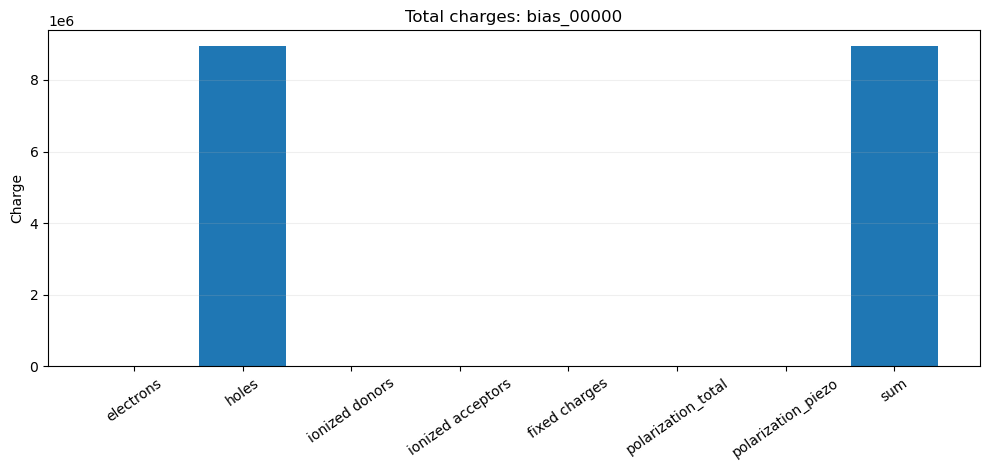

In [52]:
nnt.plot_total_charges(BIAS0, interactive=False)
plt.show()


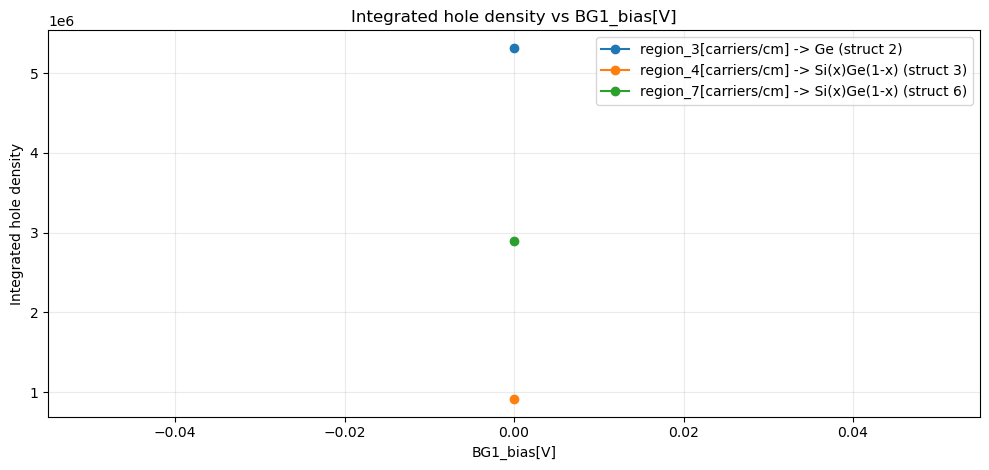

In [53]:
nnt.plot_integrated_density_hole(
    RUN_ROOT,
    interactive=False,
    label_with_materials=True,
    cut=CUT_Z,
)
plt.show()


## 3. Structure inspection


Use the structure outputs to verify that the simulated device matches the intended heterostructure and gate geometry.


In [54]:
structure_region_map = nnt.build_region_material_map(RUN_ROOT, cut=CUT_Z)
display(structure_region_map)


,structure_region_index,material_index,coord_min,coord_max,n_points,material_name,thickness_nm,cut,coordinate
0,0,16,-4065.000000,-4065.00,1,Si(x)Ge(1-x),0.000000,1d_z_BG2,y[nm]
1,1,16,-3965.345261,-15.25,201,Si(x)Ge(1-x),3950.095261,1d_z_BG2,y[nm]
2,2,8,-14.750000,-0.25,30,Ge,14.500000,1d_z_BG2,y[nm]
3,3,16,0.250000,99.95,268,Si(x)Ge(1-x),99.700000,1d_z_BG2,y[nm]
4,6,16,100.050000,100.95,10,Si(x)Ge(1-x),0.900000,1d_z_BG2,y[nm]
5,7,396,101.050000,172.00,43,Sapphire_zb,70.950000,1d_z_BG2,y[nm]


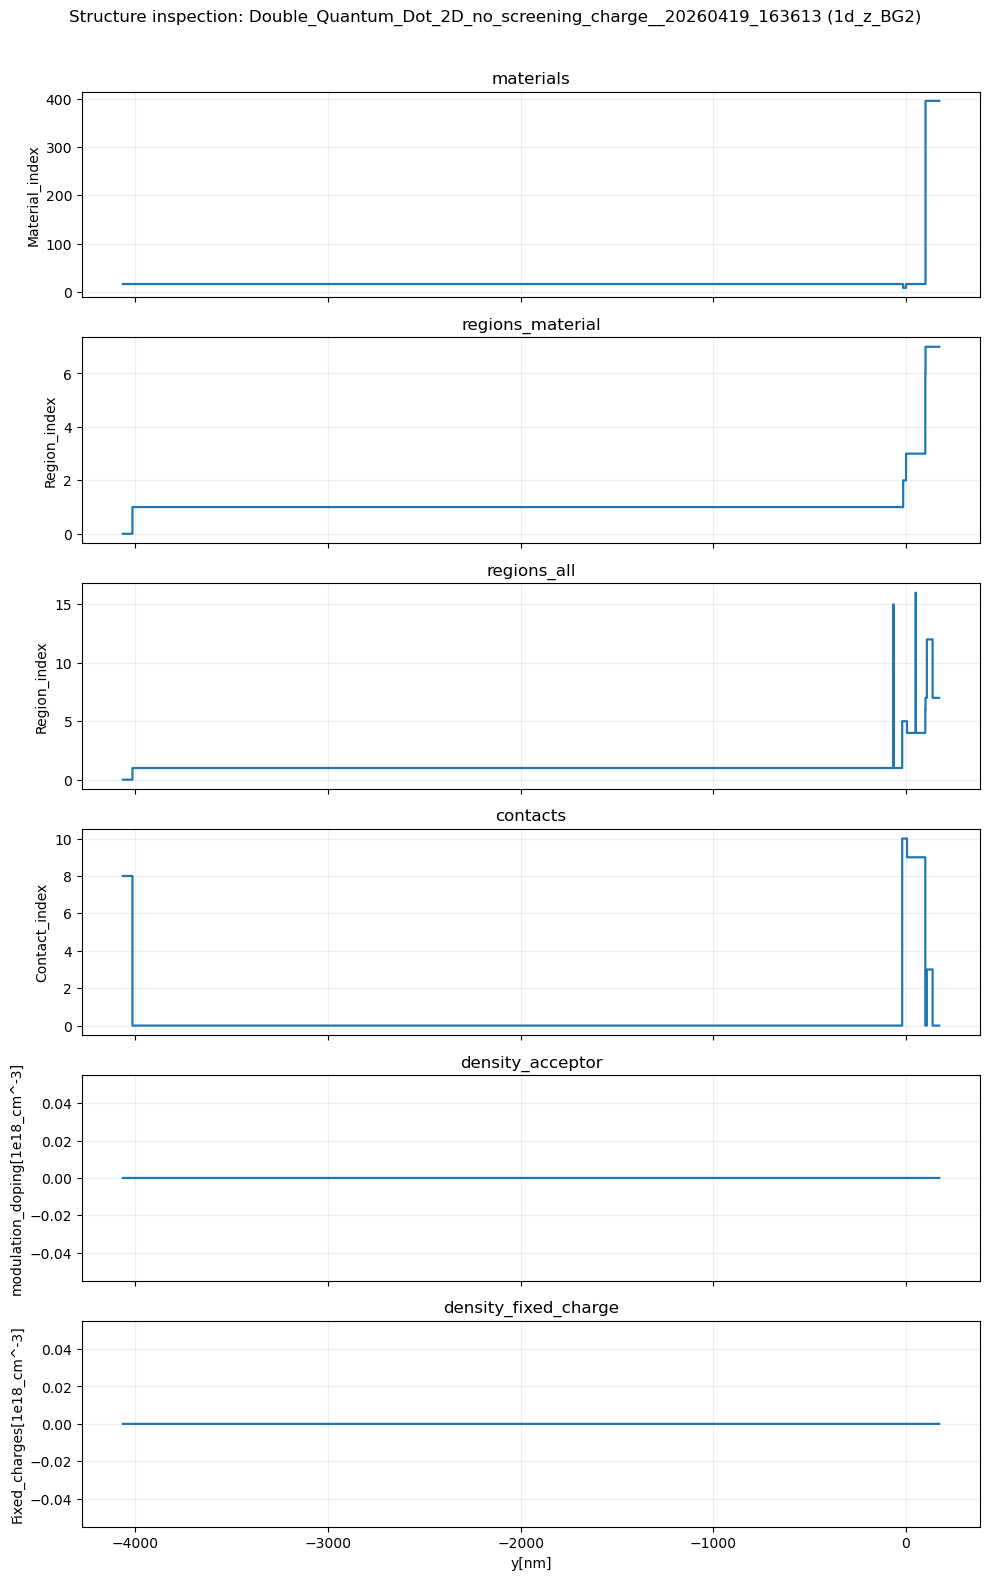

In [55]:
nnt.plot_structure_linecut(RUN_ROOT, cut=CUT_Z)
plt.show()


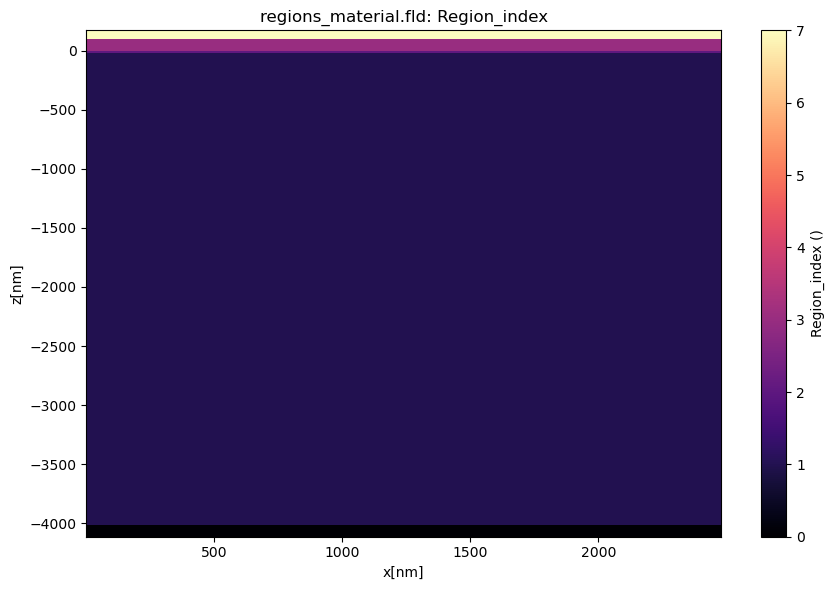

In [56]:
nnt.plot_structure_plane(RUN_ROOT, quantity='regions_material', interactive=False)
plt.show()


In [57]:
nnt.plot_structure_plane(RUN_ROOT, quantity='materials', interactive=True)


## 4. Generic file loaders and viewers


These helpers are useful when you want to inspect a particular `.dat`, `.fld`, or `.vtr` file directly without going through a quantity-specific wrapper.


In [58]:
potential_dat = BIAS0 / f'potential_{CUT_X}.dat'
bandedges_dat = BIAS0 / f'bandedges_{CUT_X}.dat'
bandedges_fld = BIAS0 / 'bandedges.fld'

print('Potential .dat description:')
print(nnt.describe_output_file(potential_dat))
print()
print('Bandedges .fld description:')
print(nnt.describe_output_file(bandedges_fld))
print()
print('Bandedges variables:', nnt.list_variables(bandedges_fld))


Potential .dat description:
{'path': '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_2D_no_screening_charge__20260419_163613/bias_00000/potential_1d_x_QD.dat', 'source': 'nextnanopy', 'ndim': 1, 'coords': {'x': {'shape': (123,), 'unit': 'nm', 'label': 'x[nm]'}}, 'variables': {'Potential': {'shape': (123,), 'unit': 'V', 'label': 'Potential (V)'}}}

Bandedges .fld description:
{'path': '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_2D_no_screening_charge__20260419_163613/bias_00000/bandedges.fld', 'source': 'nextnanopy', 'ndim': 2, 'coords': {'x': {'shape': (123,), 'unit': 'nm', 'label': 'x[nm]'}, 'z': {'shape': (554,), 'unit': 'nm', 'label': 'z[nm]'}}, 'variables': {'Gamma': {'shape': (123, 554), 'unit': 'eV', 'label': 'Gamma (eV)'}, 'Delta_1': {'shape': (123, 554), 'unit': 'eV', 'label': 'Delta_1 (eV)'}, 'Delta_2': {'shape': (123, 554), 'unit': 'eV', 'label': 'Delta_2 (eV)'}, 'Delta_3': {'shape': (123, 554), 'unit': 'eV

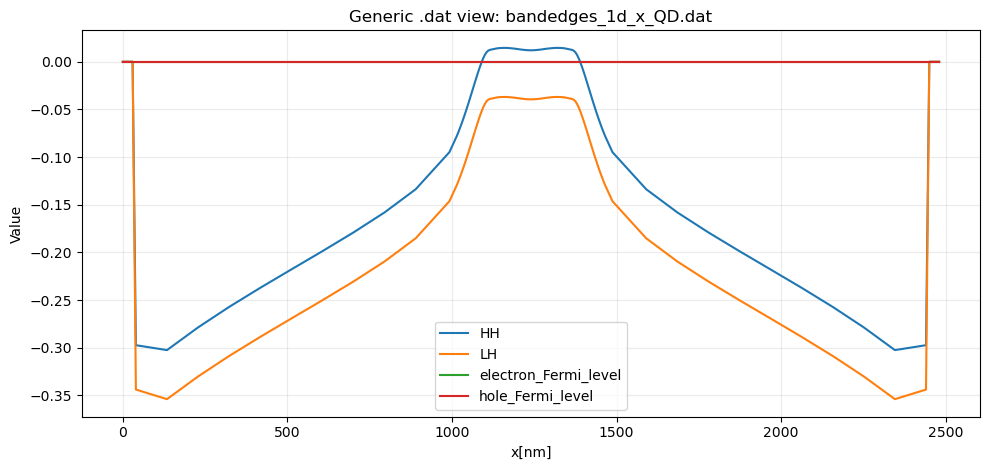

In [59]:
nnt.plot_dat(
    bandedges_dat,
    variables=['HH', 'LH', 'electron_Fermi_level', 'hole_Fermi_level'],
    title='Generic .dat view: bandedges_1d_x_QD.dat',
)
plt.show()


In [60]:
nnt.plot_dat_interactive(
    bandedges_dat,
    variables=['HH', 'LH', 'electron_Fermi_level', 'hole_Fermi_level'],
    title='Interactive .dat view: bandedges_1d_x_QD.dat',
)


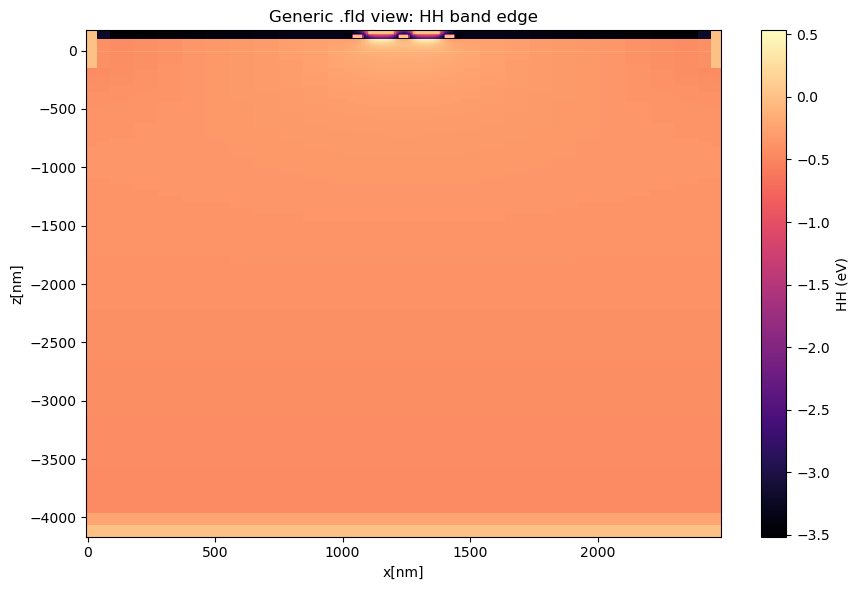

In [61]:
nnt.plot_fld(
    bandedges_fld,
    variable='HH',
    title='Generic .fld view: HH band edge',
)
plt.show()


In [19]:
nnt.plot_fld_interactive(
    bandedges_fld,
    variable='HH',
    title='Interactive .fld view: HH band edge',
)


Use `extract_linecut(...)` when you want full manual control over a slice through a `.fld` or `.vtr` dataset.

In this example we compare several `z` positions from the 2D HH band edge so you can immediately verify that the chosen depth changes the extracted profile.

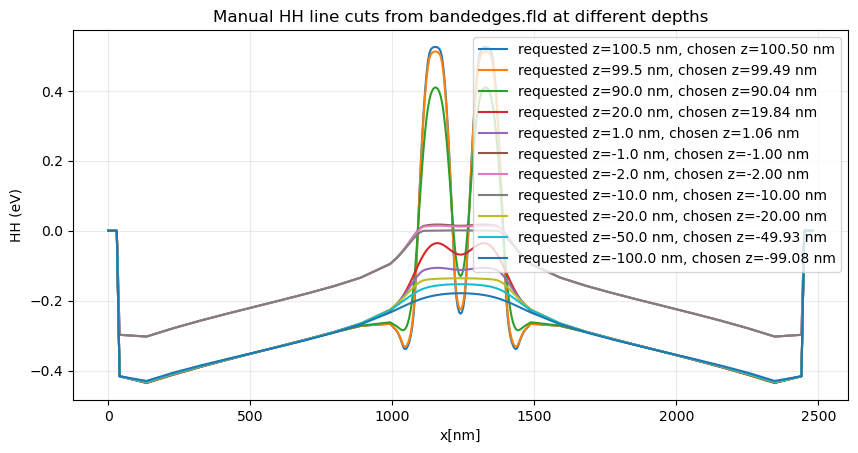

In [104]:
sample_depths = [100.5, 99.5, 90.0, 20.0, 1.0, -1.0, -2.0, -10.0, -20.0, -50.0, -100.0]
plt.figure(figsize=(10, 4.8))

for z_target in sample_depths:
    hh_line = nnt.extract_linecut(
        bandedges_fld,
        variable='HH',
        axis='x',
        fixed_coords={'z': z_target},
    )
    label = f"requested z={z_target} nm, chosen z={hh_line['chosen_coords']['z']:.2f} nm"
    plt.plot(hh_line['axis'], hh_line['values'], label=label)

plt.xlabel(hh_line['axis_label'])
plt.ylabel(hh_line['variable'].label)
plt.title('Manual HH line cuts from bandedges.fld at different depths')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

# If you want to inspect a single depth only, call extract_linecut(...) once and use
# hh_line['requested_coords'], hh_line['chosen_coords'], and hh_line['chosen_indices']
# to confirm the exact slice that was used.


## 5. Bias outputs through convenience wrappers


Once you know the quantity name, the bias wrapper functions are the quickest way to inspect the potential, electric field, densities, and band edges.


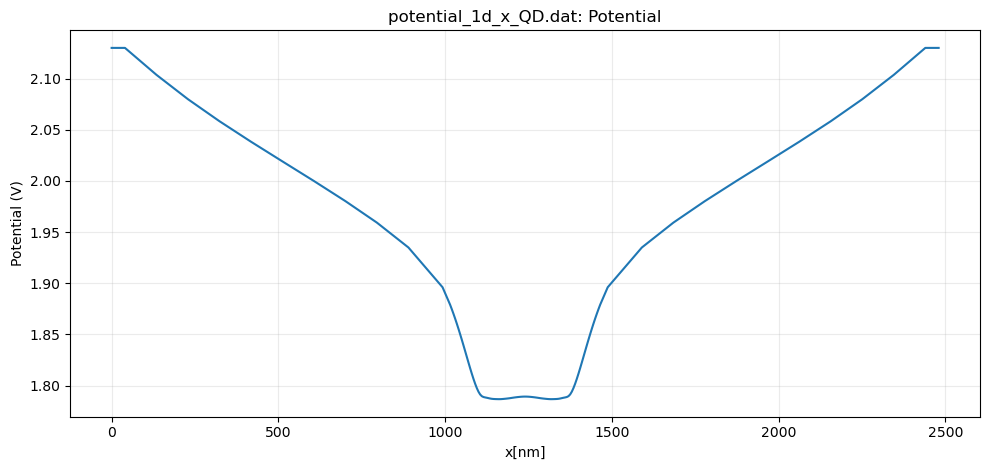

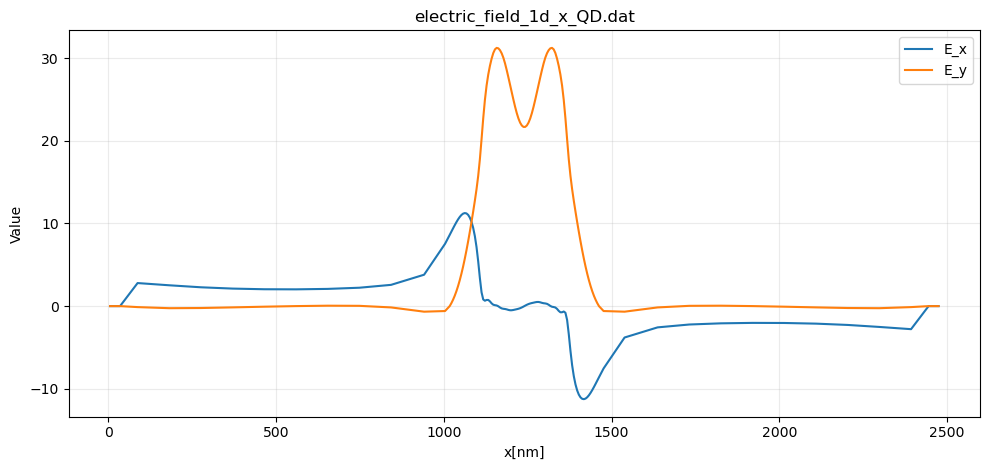

In [106]:
nnt.plot_bias_linecut(RUN_ROOT, 'potential', cut=CUT_X, interactive=False)
plt.show()

nnt.plot_bias_linecut(RUN_ROOT, 'electric_field', cut=CUT_X, interactive=False)
plt.show()


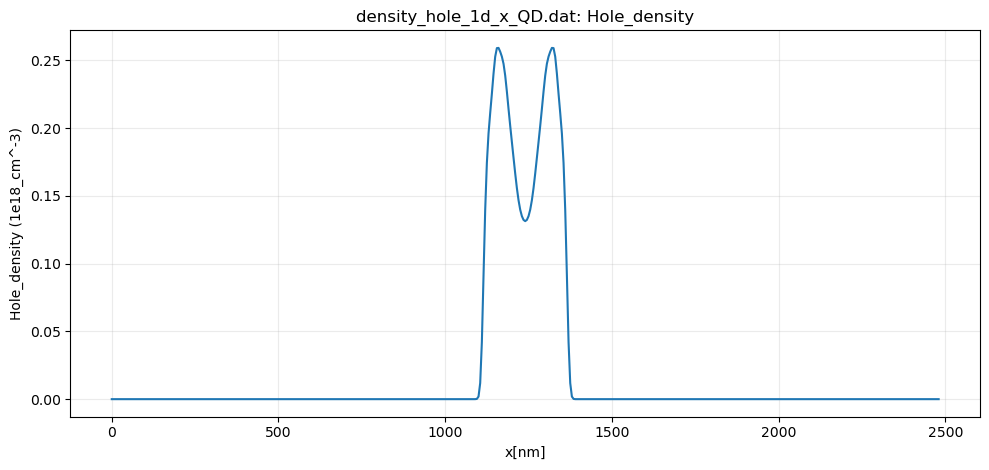

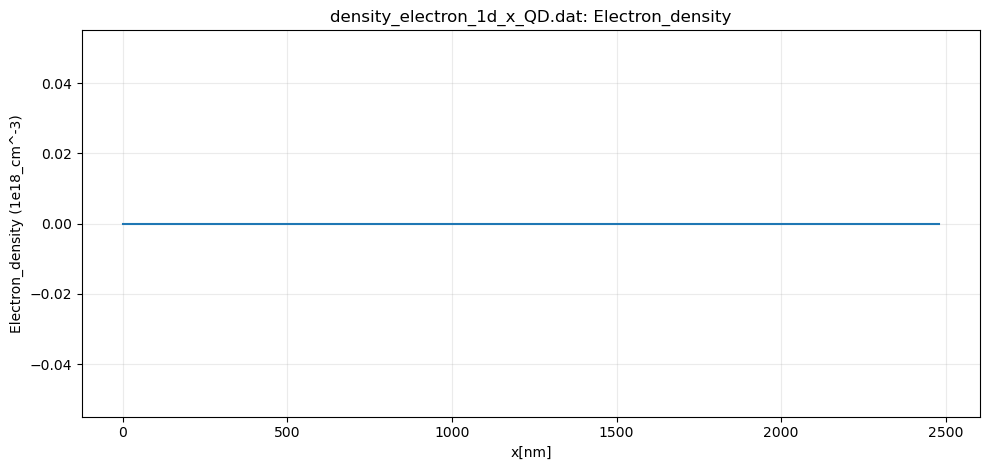

In [107]:
nnt.plot_bias_linecut(RUN_ROOT, 'density_hole', cut=CUT_X, interactive=False)
plt.show()

nnt.plot_bias_linecut(RUN_ROOT, 'density_electron', cut=CUT_X, interactive=False)
plt.show()


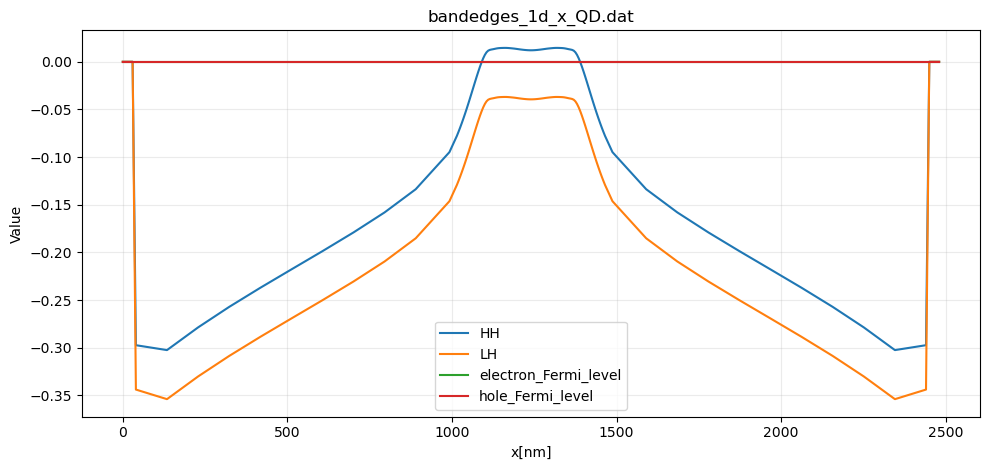

In [108]:
nnt.plot_bias_linecut(
    RUN_ROOT,
    'bandedges',
    cut=CUT_X,
    variables=['HH', 'LH', 'electron_Fermi_level', 'hole_Fermi_level'],
    interactive=False,
)
plt.show()


In [110]:
nnt.plot_bias_plane(RUN_ROOT, 'potential', interactive=True)
plt.show()

nnt.plot_bias_plane(RUN_ROOT, 'electric_field_norm', interactive=True)
plt.show()

nnt.plot_bias_plane(RUN_ROOT, 'density_hole', interactive=True, log10=True)
plt.show()

nnt.plot_bias_plane(RUN_ROOT, 'density_electron', interactive=True, log10=True)
plt.show()


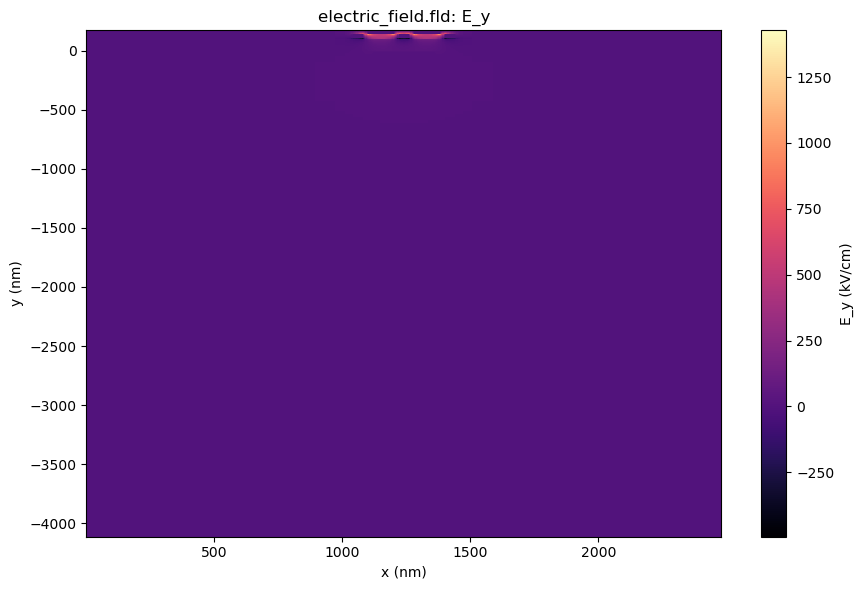

In [40]:
nnt.plot_bias_plane(RUN_ROOT, 'electric_field', variable='E_y', interactive=False)
plt.show()

nnt.plot_bias_plane(RUN_ROOT, 'bandedges', variable='HH', interactive=True)


## 6. Quantum outputs


This section focuses on the quantum subfolder. For this run, the most relevant outputs are the HH and LH densities, spectra, occupations, and `probabilities_shift` files.


In [111]:
hh_occ = nnt.read_quantum_occupation(RUN_ROOT, region=QUANTUM_REGION, band=QUANTUM_BAND)
hh_spec = nnt.read_quantum_energy_spectrum(RUN_ROOT, region=QUANTUM_REGION, band=QUANTUM_BAND)

display(hh_occ.head(10))
display(hh_spec.head(10))


,no.,Occupation[holes_cm^-1]
0,1,758936.925859
1,2,758726.306500
2,3,676974.515050
3,4,669975.039920
4,5,608896.253393
5,6,567664.571483
6,7,501106.988093
7,8,419558.776768
8,9,304412.609268
9,10,73333.736779


,no.,Energy[eV]
0,1,0.001639
1,2,0.001639
2,3,0.001305
3,4,0.001278
4,5,0.001055
5,6,0.000917
6,7,0.000715
7,8,0.000501
8,9,0.000264
9,10,0.000015


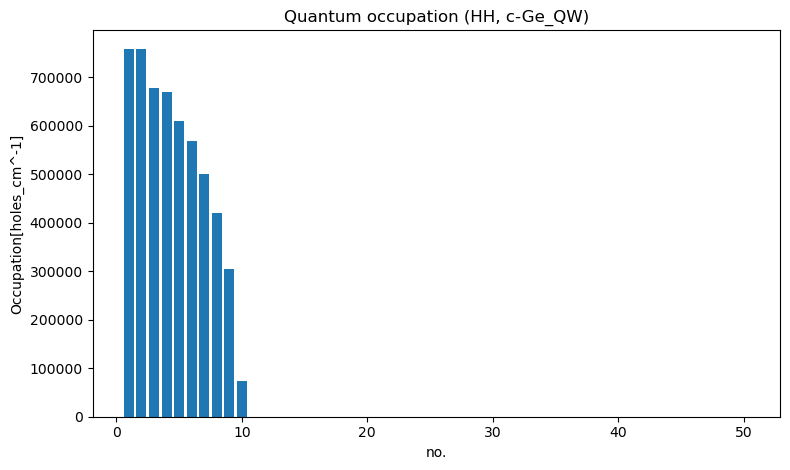

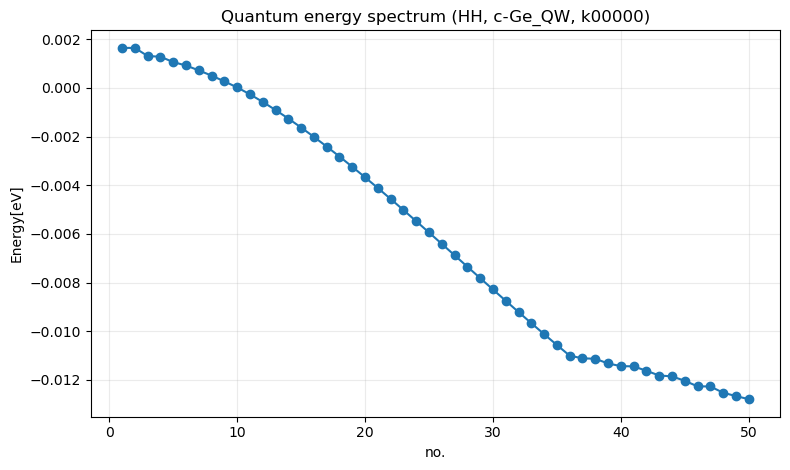

In [112]:
nnt.plot_quantum_occupation(RUN_ROOT, region=QUANTUM_REGION, band=QUANTUM_BAND, interactive=False)
plt.show()

nnt.plot_quantum_energy_spectrum(RUN_ROOT, region=QUANTUM_REGION, band=QUANTUM_BAND, interactive=False)
plt.show()


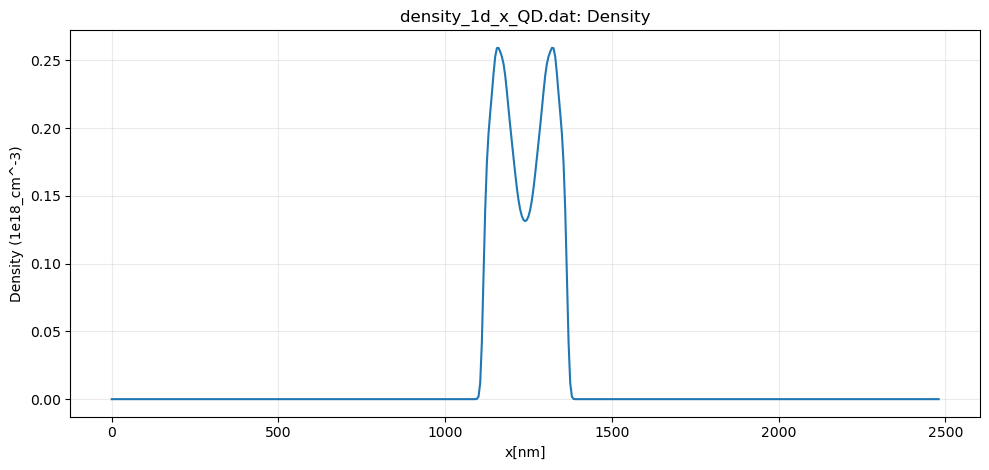

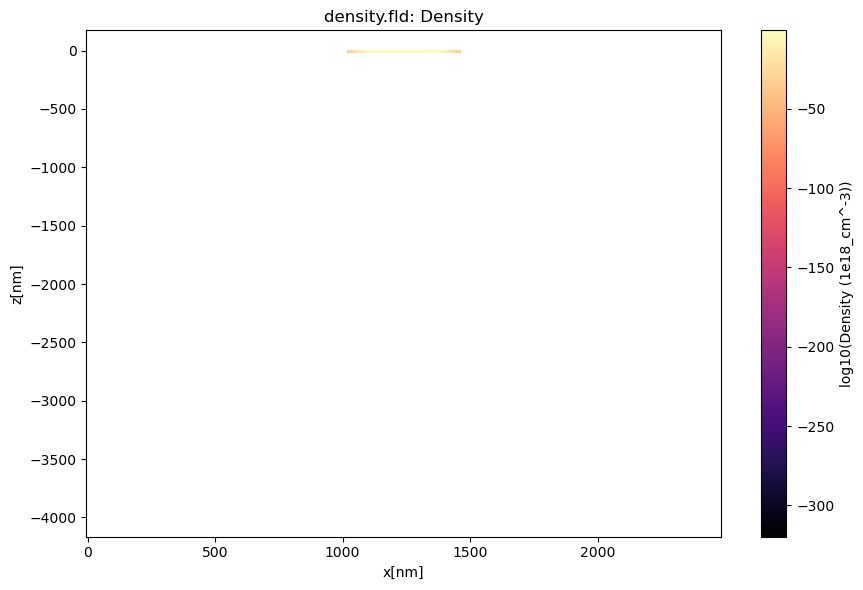

In [113]:
nnt.plot_quantum_linecut(
    RUN_ROOT,
    quantity='density',
    cut=CUT_X,
    region=QUANTUM_REGION,
    band=QUANTUM_BAND,
    interactive=False,
)
plt.show()

nnt.plot_quantum_plane(
    RUN_ROOT,
    quantity='density',
    region=QUANTUM_REGION,
    band=QUANTUM_BAND,
    interactive=False,
    log10=True,
)
plt.show()


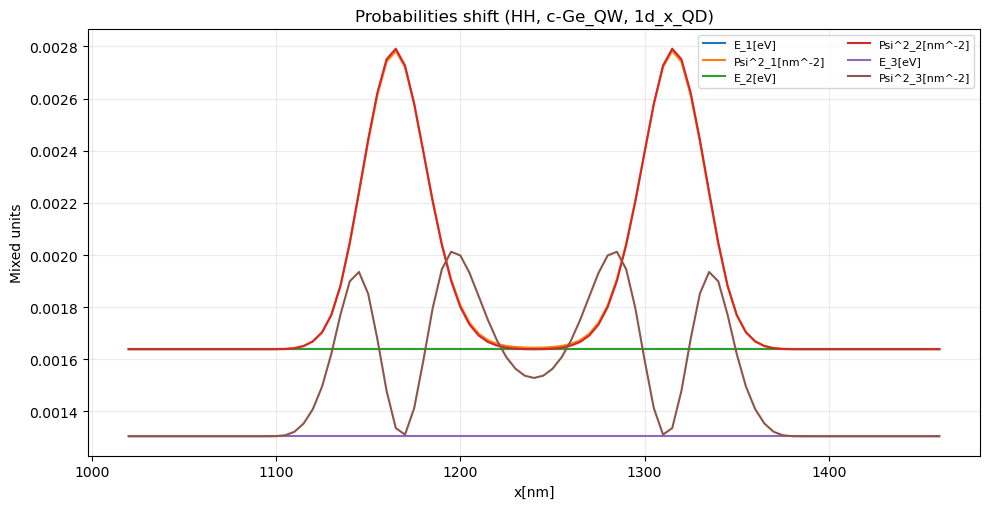

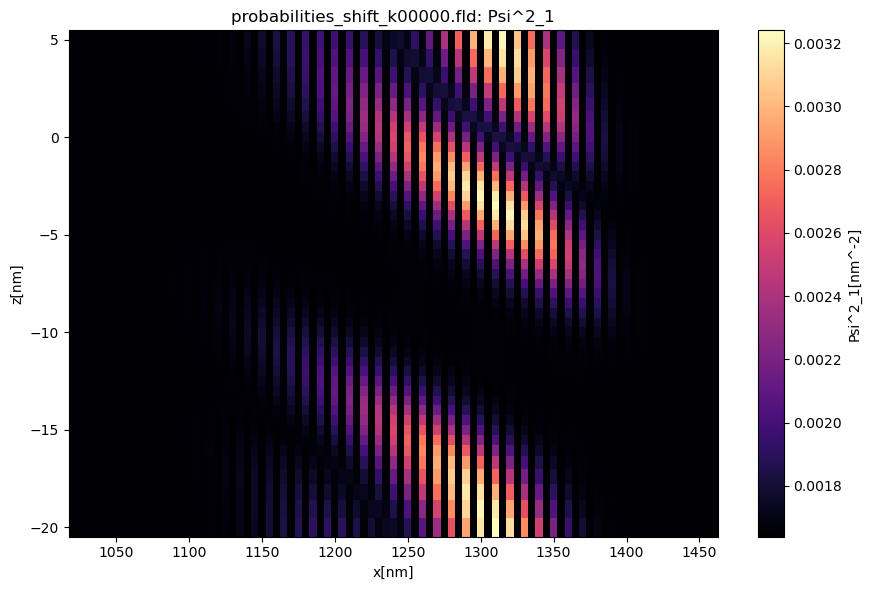

In [114]:
nnt.plot_quantum_probabilities_linecut(
    RUN_ROOT,
    cut=CUT_X,
    states=(1, 2, 3),
    region=QUANTUM_REGION,
    band=QUANTUM_BAND,
    interactive=False,
)
plt.show()

nnt.plot_quantum_probability_plane(
    RUN_ROOT,
    state=1,
    region=QUANTUM_REGION,
    band=QUANTUM_BAND,
    interactive=False,
)
plt.show()


## 7. Optional: `.vtr` helpers for 3D runs


This 2D example does not produce `.vtr` files, but the same module also supports 3D rectilinear outputs through nextnanopy. The cell below shows how to detect `.vtr` files and how the calls look for 3D runs.


In [45]:
vtr_files = sorted(RUN_ROOT.rglob('*.vtr'))
print('Found .vtr files:', [str(path.relative_to(RUN_ROOT)) for path in vtr_files[:10]])

if vtr_files:
    vtr_path = vtr_files[0]
    vtr_variables = nnt.list_variables(vtr_path)
    print('Using:', vtr_path)
    print('Variables:', vtr_variables)

    nnt.plot_vtr_slice(vtr_path, variable=vtr_variables[0], slice_axis='y')
    plt.show()

    nnt.plot_vtr_slice_interactive(vtr_path, variable=vtr_variables[0], slice_axis='y')

    nnt.plot_vtr_linecut(
        vtr_path,
        variable=vtr_variables[0],
        axis='x',
        fixed_coords={'y': 0.0, 'z': -7.0},
        interactive=False,
    )
    plt.show()
else:
    print('No .vtr files are present in this 2D run.')
    print('For a 3D run, use plot_vtr_slice(...), plot_vtr_slice_interactive(...), and plot_vtr_linecut(...).')


Found .vtr files: []
No .vtr files are present in this 2D run.
For a 3D run, use plot_vtr_slice(...), plot_vtr_slice_interactive(...), and plot_vtr_linecut(...).


## 8. Optional: sweep example


This is an example of how to run a native nextnanopy sweep from the same notebook. It is intentionally guarded by `if False:` so that it does not start automatically.


In [ ]:
if False:
    sweep_root = RUNS_ROOT / f"{INPUT_PATH.stem}_sweep__{nnt.make_timestamp_tag()}"

    sweep = nnt.run_sweep(
        INPUT_PATH,
        {
            'V_PG1': [-2.8, -3.0, -3.2],
            'V_PG2': [-2.8, -3.0, -3.2],
        },
        show_log=False,
        convergenceCheck=True,
        parallel_limit=1,
        execute_kwargs={'outputdirectory': sweep_root},
    )

    subrun = nnt.find_sweep_subrun(sweep_root, V_PG1=-3.0, V_PG2=-3.0)
    print('Sweep object:', sweep)
    print('Example subrun:', subrun)


## 9. Reuse checklist


When you copy this notebook for another device or simulation:

1. Change `INPUT_PATH`.
2. Set `RUN_TAG` if you want a human-readable label appended to the timestamped run name.
3. Set `FORCE_RERUN = True` when you want to generate a new run, or keep `REUSE_LATEST_RUN = True` to inspect the latest matching one.
4. Update `CUT_X`, `CUT_Z`, `QUANTUM_REGION`, and `QUANTUM_BAND` if needed.
5. Keep the same sections and replace or extend the plots that matter for your new case.
